### Set up Project Variables and Import Database

In [28]:
from langchain_community.graphs import Neo4jGraph
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from langchain_nvidia_ai_endpoints import ChatNVIDIA
import os
from dotenv import load_dotenv


load_dotenv() # Load environment variables from .env file


NEO4J_URI = os.getenv("NEO4J_URI")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
NEO4J_URI=os.getenv("NEO4J_URI")
NEO4J_USERNAME=os.getenv("NEO4J_USERNAME")
NEO4J_PASSWORD=os.getenv("NEO4J_PASSWORD")
os.environ["NEO4J_URI"] = NEO4J_URI
os.environ["NEO4J_USERNAME"] = "neo4j"
os.environ["NEO4J_PASSWORD"] = NEO4J_PASSWORD

graph = Neo4jGraph()
llm=ChatGroq(model="llama-3.3-70b-versatile", temperature=0)

In [ ]:
# os.environ.clear()

In [22]:
llm.invoke("What is Neo4j?").content

"**Neo4j Overview**\n===============\n\nNeo4j is a graph database management system designed to store and query large amounts of data as nodes and relationships. It is a NoSQL database, which means it does not use the traditional table-based structure of relational databases.\n\n**Key Features**\n---------------\n\n* **Graph Data Model**: Neo4j stores data as nodes (entities) and relationships (connections between entities).\n* **Query Language**: Cypher, a declarative query language, is used to query and manipulate data in Neo4j.\n* **Scalability**: Neo4j is designed to handle large amounts of data and scale horizontally.\n* **ACID Compliance**: Neo4j supports atomicity, consistency, isolation, and durability (ACID) properties to ensure database consistency.\n\n**Use Cases**\n-------------\n\n* **Social Network Analysis**: Neo4j is well-suited for analyzing complex social networks and relationships.\n* **Recommendation Systems**: Neo4j can be used to build recommendation systems based

In [29]:
graph.get_schema

'Node properties:\n\nRelationship properties:\n\nThe relationships:\n'

### Source extraction from PDF

In [ ]:
from utilities import extract_pdf_chunks, save_chunks_to_file

pdf_path="data/pdf/Commercial Exchange CHIP PT Minutes Sept 2024 eVote.pdf"

chunks = extract_pdf_chunks(pdf_path)
save_chunks_to_file(chunks, "data/text/drugs_context.txt")

#### 1. Knowledge creation 

The next step is to extract knowledge from our sources. In this step, we have to extract triplets (or a set of facts) from a text corpus or another source (a database, or structured and unstructured data). Two tasks can be defined:

* **Named entity recognition (NER)**: NER is the task of extracting entities from text and classifying them
* **Relation extraction (RE)**: RE is the task of identifying connections between various entities in a context 

NER is one of the most common tasks in natural language processing (NLP) and is used not only for KG creation but also as a key step when we want to move from unstructured text to structured data.\
It generally requires a pipeline consisting of several steps (text preprocessing, entity identification and classification, contextual analysis, and data post-processing).\
During NER, we try to identify entities by first conducting a preprocessing step to avoid errors in the pipeline (e.g., proper tokenization).
Once entities are identified, they are usually classified (e.g., by adding a label such as people, organizations, or places).\
In addition, surrounding text is attempted to be used to disambiguate them (e.g., trying to recognize whether Apple in the text represents the fruit or the company). A preprocessing step is then conducted to resolve ambiguities or merge multi-token entities.

Eg. of NER - 
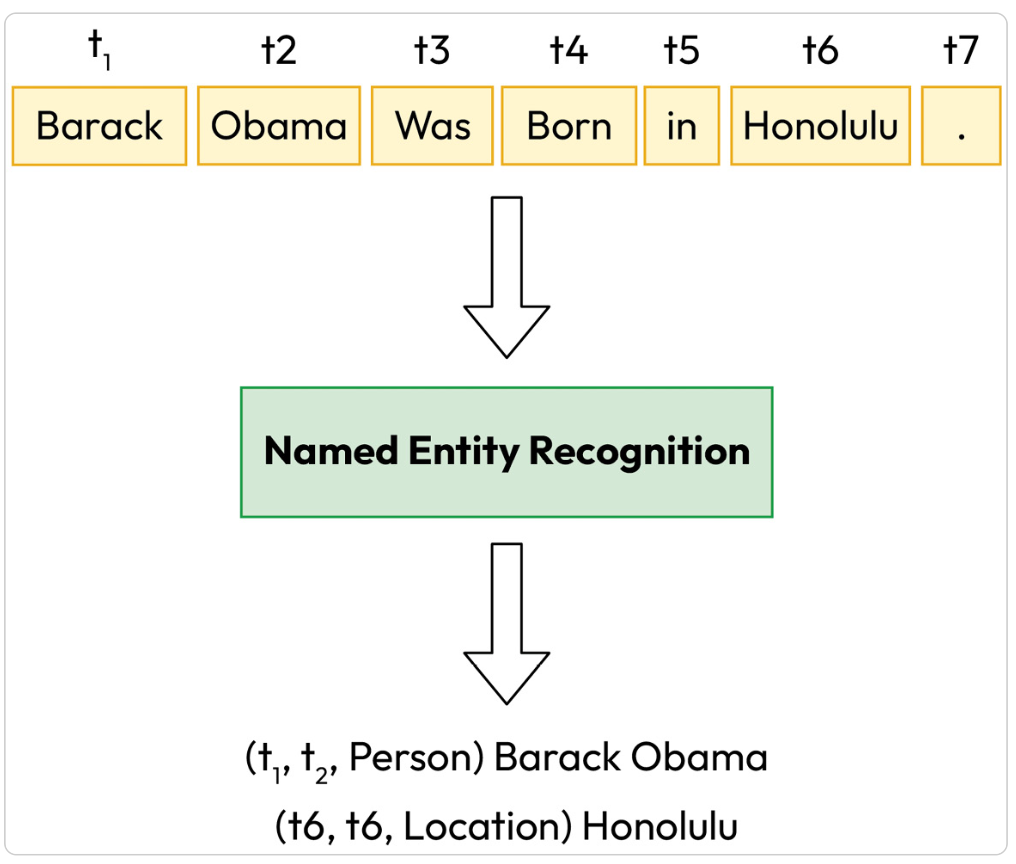

#### Two methods:

1. Custom Method
2. Langchain Graph Transformers

In [39]:
#Custom method

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import SystemMessage
from langchain_core.output_parsers import StrOutputParser


prompt = ChatPromptTemplate.from_messages([
    SystemMessage(content="""
    You are a helpful assistant in creates knowledge graphs by Generating Cypher Queries.\n

    Task:
     *  Identify Entities, Relationships and Property Keys from Context.\n
     *  Generate Cypher Query to Create Knowledge Graph from the Entities Relationships and Property Keys discovered.\n
     *  Extract ALL Entities and RelationShips as Possible.\n
     *  Always extract a person Profession as an Entity.\n
     *  Be creative.
     *  Understand hidden relationships from the network.
     Note: Read the Context twice and carefully before generating Cypher Query.\n
     Note: Do not return anything other than the Cypher Query.\n
     Note: Do not include any explanations or apologies in your responses.\n


     Note: Do not hallucinate.\n

     Entities include Person, Place, Product, WorkPlaces, Companies , City, Country, Animals, Tags like peoples Profession and more \n

     Few Shot Prompts:
      Example Context:

       WINREVAIR is a hypertension drug whose formulary alternative is Bosentan which is also 
        a formulary alternative for OPSYNVI. Both WINREVAIR and OPSYNVI have GPI level of 12.
                  
      Answer:
        MERGE (WINREVAIR:Drug {name: "WINREVAIR", review: "Winrevair is an activin signaling inhibitor indicated for the treatment of adults with pulmonary arterial hypertension (PAH, WHO Group 1) to increase exercise capacity, improve WHO functional class (FC) and reduce the risk of clinical worsening events.",clinical_discussion: "No comments or questions. The committee unanimously voted to accept the recommendations as presented (36 approvals). None were opposed.",authorization_duration: "Initial authorization will be for 6 months.",quantity_limit:
            "• 45 mg x 1 (1 mL) Syringe Kit (NDC 0006-5090-01) – 2 Kits (2 milliliter) per 21 days
            • 60 mg x 1 (1.3 mL) Syringe Kit (NDC 0006-5091-01) – 2 Kits (2.6 milliliter) per 21 days • 45 mg x 2 (1 mL) Syringes Kit (NDC 0006-5087-01) – 1 Kits (2 milliliter) per 21 days
            • 60 mg x 2 (1.3 mL) Syringes Kit (NDC 0006-5088-01) – 1 Kits (2.6 milliliter) per 21 days",formulary_alternatives:
            "endothelin receptor antagonist (ERA) : ambrisentan*, bosentan*, Opsumit*, Tracleer*
            phosphodiesterase-5 inhibitor (PDE5i) :alyq*, sildenafil 20 mg tablet*, sildenafil 10 mg/mL suspension*, tadalafil (pah) 20 mg tab*
            soluble guanylate cyclase (sGC) stimulator : Adempas*
            Prostaglandin Vasodilators: epoprostenol*, treprostinil*, Tyvaso*, Tyvaso DPI*, Ventavis*",GPI_level: "GPI-12"})
        MERGE (OPSYNVI:Drug {name: "OPSYNVI", review:"Opsynvi is a combination drug that contains macitentan and tadalafil.",clinical_discussion:"Dr. Bret Yarczower asked if we could send the chart on the cost to his clinical colleagues who treat PAH. Emily Bednarz, PharmD, stated she can send the chart to Dr. Yarczower. The committee unanimously voted to accept the recommendations as presented (36 approvals). None were opposed.",quantity_limit: "30 tablets per 30 days",formulary_alternatives: "Ambrisentan tablet, Bosentan tablet, Opsumit tablet, Tracleer 32mg tablet, Sildenafil tablet, Sildenafil Suspension, Alyq tablet, Tadalafil tablet"})
        MERGE (WINREVAIR)-[:Common_formulary_alternatives]->(OPSYNVI)
        MERGE (OPSYNVI)-[:Common_formulary_alternatives]->(WINREVAIR)
        MERGE (WINREVAIR)-[:Has_GPI_level]->(Max:GPI_level {name: "WINREVAIR", value: "GPI-12"})


    """),
    ("human", "Context:{text}"),
])

chain  = prompt | llm | StrOutputParser()

In [40]:

content = ""
# Open the file in read mode
with open('drugs_context.txt', 'r') as file:
    # Read the contents of the file
    content = file.read()

In [44]:
# before doing chain.invoke check if TPM exceed the limit of 12000 and if it then wait for 1 min and then invoke for next 12000 tokens and repeat the process until all the content is processed. You can use time module to implement the waiting mechanism.
def invoke_with_retry(chain, content, max_tokens=10000):
    import time

    # Split the content into chunks based on approximate token count
    # More conservative estimate: 1 token ≈ 4.5 characters (accounting for prompt overhead)
    chunks = []
    current_chunk = ""
    current_token_estimate = 0
    
    # Estimate tokens in the system prompt (approximate)
    system_prompt_tokens = 1500

    sentences = content.split('. ')
    
    for sentence in sentences:
        sentence = sentence.strip()
        if not sentence:
            continue
            
        # Estimate tokens for this sentence (1 token ≈ 4.5 characters)
        sentence_tokens = len(sentence) // 4.5 + 1
        
        # Check if adding this sentence would exceed limit (accounting for system prompt)
        if current_token_estimate + sentence_tokens + system_prompt_tokens > max_tokens:
            if current_chunk:
                chunks.append(current_chunk.strip())
            current_chunk = sentence + ". "
            current_token_estimate = sentence_tokens
        else:
            current_chunk += sentence + ". "
            current_token_estimate += sentence_tokens
    
    # Add any remaining content
    if current_chunk:
        chunks.append(current_chunk.strip())

    results = []
    for i, chunk in enumerate(chunks):
        print(f"Processing chunk {i+1} of {len(chunks)}")
        result = chain.invoke({"text": chunk})
        results.append(result)
        # Wait for 65 seconds before processing the next chunk (to reset rate limit)
        if i < len(chunks) - 1:
            print(f"Waiting 65 seconds before next chunk...")
            time.sleep(65)

    return results

result = invoke_with_retry(chain, content)

# Print results
for i, r in enumerate(result):
    print(f"\n--- Chunk {i+1} Result ---")
    print(r)

Processing chunk 1 of 4
Waiting 65 seconds before next chunk...
Processing chunk 2 of 4
Waiting 65 seconds before next chunk...
Processing chunk 3 of 4
Waiting 65 seconds before next chunk...
Processing chunk 4 of 4

--- Chunk 1 Result ---
```cypher
MERGE (TECELRA:Drug {name: "TECELRA", review: "Tecelra is a melanoma-associated antigen A4 (MAGE-A4)-directed genetically modified autologous T cell immunotherapy indicated for the treatment of adults with unresectable or metastatic synovial sarcoma who have received prior chemotherapy, are HLA-A*02:01P, -A*02:02P, -A02:03P, or -A02:06P positive and whose tumor expresses the MAGE-A4 antigen as determined by FDA-approved or cleared companion diagnostic devices.", clinical_discussion: "No comments or questions. The committee unanimously voted to accept the recommendations as presented (36 approvals). None were opposed.", authorization_duration: "One-time authorization for one administration of Tecelra", quantity_limit: "Not specified", formul

In [45]:
def create_knowledge_graph(cypher:str):
    graph.query(cypher)

In [47]:
# Extract and execute each Cypher query from the results
for i, cypher_block in enumerate(result):
	try:
		# Remove markdown code block markers if present
		cypher_query = cypher_block.replace("```cypher\n", "").replace("```", "").strip()
		
		if cypher_query:  # Only execute if query is not empty
			print(f"\nExecuting query {i+1}...")
			create_knowledge_graph(cypher_query)
			print(f"Query {i+1} executed successfully")
	except Exception as e:
		print(f"Error executing query {i+1}: {e}")


Executing query 1...
Query 1 executed successfully

Executing query 2...
Query 2 executed successfully

Executing query 3...
Error executing query 3: {neo4j_code: Neo.ClientError.Statement.SyntaxError} {message: Can't create node `RA` with labels or properties here. The variable is already declared in this context} {gql_status: 42N78} {gql_status_description: error: syntax error or access rule violation - variable already bound. Node `RA` has already been bound and cannot be modified by the MERGE clause.}

Executing query 4...
Query 4 executed successfully


### Querying the graph

In [50]:
from langchain_neo4j import GraphCypherQAChain

graphchain = GraphCypherQAChain.from_llm(
    llm, graph=graph, verbose=True, return_intermediate_steps=True,allow_dangerous_requests=True
)

In [58]:
results = graphchain.invoke({"query":"Details of drug name TECELRA "})
print(results["result"])



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (n:Drug {name: "TECELRA"}) RETURN n
Full Context:
[{'n': {'clinical_discussion': 'No comments or questions. The committee unanimously voted to accept the recommendations as presented (36 approvals). None were opposed.', 'formulary_alternatives': 'Not specified', 'review': 'Tecelra is a melanoma-associated antigen A4 (MAGE-A4)-directed genetically modified autologous T cell immunotherapy indicated for the treatment of adults with unresectable or metastatic synovial sarcoma who have received prior chemotherapy, are HLA-A*02:01P, -A*02:02P, -A02:03P, or -A02:06P positive and whose tumor expresses the MAGE-A4 antigen as determined by FDA-approved or cleared companion diagnostic devices.', 'GPI_level': 'Not specified', 'quantity_limit': 'Not specified', 'authorization_duration': 'One-time authorization for one administration of Tecelra', 'name': 'TECELRA'}}]

> Finished chain.
TECELRA is a melanoma-associated antigen A4 (M

### **List all node labels**

In [71]:
labels=[r["label"] for r in graph.query("CALL db.labels() YIELD label RETURN label")]
print(labels)

['Drug', 'Person', 'Disease', 'Meeting', 'Formulary_Alternatives', 'GPI_level', 'Warning', 'Dosing', 'Quantity_Limit', 'Profession', 'Concept', 'Site_of_Care', 'Program']


### **List all Global Properties**

In [77]:
property_rows=[r["propertyKey"] for r in graph.query("CALL db.propertyKeys() YIELD propertyKey RETURN propertyKey")]
print(property_rows)

['clinical_discussion', 'formulary_alternatives', 'review', 'GPI_level', 'quantity_limit', 'authorization_duration', 'name', 'profession', 'value', 'description', 'type']


### **List all relationship types** 

In [76]:
relationship=[r["relationshipType"] for r in graph.query("CALL db.relationshipTypes() YIELD relationshipType RETURN relationshipType")]
print(relationship)

['Indicated_for', 'Participated_in', 'Has_formulary_alternatives', 'Has_GPI_level', 'Discussed', 'Treated_by', 'Discussed_by', 'Add_on_therapy_to', 'Formulary_alternative', 'Used_for', 'Has_black_box_warning', 'Has_warning', 'Has_dosing', 'Has_quantity_limit', 'Treated_disease', 'Treats', 'Prescribes', 'Has_Biosimilars', 'Not_Concurrently_Used_With', 'Therapeutic_Failure_On', 'Formulary_Alternative', 'Prior_Authorization']


### **Prompting**

In [79]:
graph_prompt = ChatPromptTemplate.from_messages([
  ("system",
   f"""
    You are a Cypher Expert Generating Cypher Queries to query a Neo4j Database from User Questions.\n

    Task:
      *  Use the schema provided to generate Cypher Queries.\n
      *  Strictly follow the schema while generating Cypher Queries.\n
      *  Do not return any explanations or apologies in your responses.\n
      *  Do not return anything other than cypher queries.
      * use fullnames for cypher variables

    """),
    ("human","Schema: {schema}"),
    ("human","The question is: {query}") ,

  ]
)

qa_prompt = ChatPromptTemplate.from_messages([
    ("system","""
    You are a Chat Assistant helping users with their queries.
    Task: You are to generate answers to the Question asked using the result from context provided. Be concise and provide all relevant information from context.

    Instructions:
    - Read the question and the context again before answering.
    - Use only the provided context to answer the question.
    - If no context is provided, explain to the user you could not find that information.
    - Do not fall back to your pre-trained knowledge.
    - Do not mention context in your answer.
    - Be as helpful as you can.
    - Do not hallucinate.
    - Make sure to provide answer from context before saying you don't know.



    Note: The context provided comes from an Authoritative and is a fact source do not doubt it .
    Note: Do not fallback to your pre-trained knowledge.
    Note: Provide the answer an do not mention you are providing the answer from the context.

    *Be friendly with your with your tone.
    """),

    ("human","Question:{question}"),
    ("human","Context:{context}"),
])

second_graphQa = GraphCypherQAChain.from_llm(
    llm=llm, qa_llm=llm,  graph=graph, verbose=True, cypher_prompt=graph_prompt, return_intermediate_steps=True, qa_prompt=qa_prompt,allow_dangerous_requests=True
)

In [80]:
result = second_graphQa.invoke({"query":"Details of drug name TECELRA?"})
print(result["result"])



> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (DrugNode:DrugNode {name: "TECELRA"}) RETURN DrugNode


Received notification from DBMS server: <GqlStatusObject gql_status='01N50', status_description='warn: label does not exist. The label `DrugNode` does not exist in database `neo4j`. Verify that the spelling is correct.', position=<SummaryInputPosition line=1, column=17, offset=16>, raw_classification='UNRECOGNIZED', classification=<NotificationClassification.UNRECOGNIZED: 'UNRECOGNIZED'>, raw_severity='WARNING', severity=<NotificationSeverity.WARNING: 'WARNING'>, diagnostic_record={'_classification': 'UNRECOGNIZED', '_severity': 'WARNING', '_position': {'offset': 16, 'line': 1, 'column': 17}, 'OPERATION': '', 'OPERATION_CODE': '0', 'CURRENT_SCHEMA': '/'}> for query: 'MATCH (DrugNode:DrugNode {name: "TECELRA"}) RETURN DrugNode'


Full Context:
[]

> Finished chain.
I don't know the details of the drug name TECELRA.
